# **Time Series Decomposition**

## <span style="color:grey;"> **1. Time Series Components** </span>

#### Load Common libraries and settings

In [4]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
import numpy as np
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

#### Load additional libraries

In [2]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

#### **Decomposition of time series components**

The time can be decomposed with the following models:

- Additive decomposition
- Multiplicative decomposition
- Pseudoadditive decomposition

**Additive Model**

Additive models assume that the observed time series is the sum of its components:

$$X(t) = T(t) + S(t) + R(t)$$
where $X(t)$ is the data, $S(t)$ is the seasonal component, $T(t)$ is the trend-cycle component, and $R(t)$ is the remainder component, all at period t. Additive models are used when the magnitudes of the seasonal and residual values do not depend on the level of the trend.

**Multiplicative Model**

Assumes that the observed time series is the product of its components:
$$X(t) = T(t) * S(t) * R(t)$$
When the variation in the seasonal pattern, or the variation around the trend-cycle, appears to be proportional to the level of the time series, then a multiplicative decomposition is more appropriate. Multiplicative decompositions are common with economic time series.

An alternative to using a multiplicative decomposition is to first transform the data until the variation in the series appears to be stable over time, then use an additive decomposition. When a log transformation has been used, this is equivalent to using a multiplicative decomposition on the original data because
$$log(X_t) = log(T_t) + log(S_t) + log(R_t)$$

**Pseudoadditive Model**

Pseudoadditive models combine elements of the `additive` and `multiplicative` models. It is useful when:
- Time series values are close to or equal to zero. Multiplicative models struggle with zero values, but you still need to model multiplicative seasonality.
- Some features are multiplicative (e.g., seasonal effects) and other are additive (e.g., residuals).
- Complex seasonal patterns or data that do not completely align with additive or multiplicative model.

For example, this model is particularly relevant for modeling series that:
- are extremely weather-dependent,
- have sharply pronounced seasonal fluctuations and trend-cycle movements.

The formulation of such models are as follows:
$$X(t) = T(t) + T(t) \cdot (S(t)-1) + T(t) \cdot (R(t)-1) = T(t) \cdot (S(t) + R(t) - 1)$$

Let us now look at a simple example to build **three different time series** using these models.

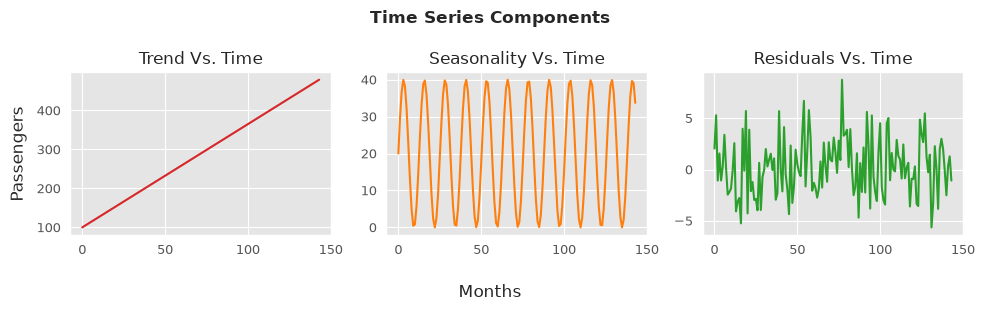

In [14]:
time = np.arange(144)
trend = time * 2.65 +100
seasonal = 20 + np.sin( time * 0.5) * 20
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].plot(time, trend, color='tab:red')
ax[1].plot(time, seasonal, color='tab:orange')
ax[2].plot(time, residuals, color='tab:green')
ax[0].set_title("Trend Vs. Time")
ax[1].set_title("Seasonality Vs. Time")
ax[2].set_title("Residuals Vs. Time")

for a in ax:
    a.grid(True)

fig.supxlabel('Months')
fig.supylabel('Passengers')
fig.suptitle('Time Series Components',fontweight='bold')
fig.tight_layout()

plt.show()

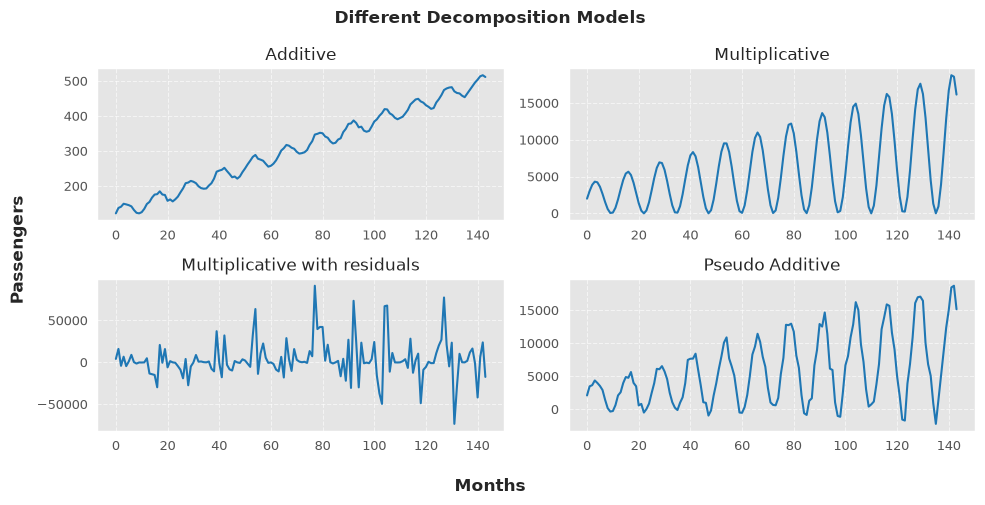

In [22]:
additive = trend + seasonal + residuals
multiplicative_wr = trend * seasonal * residuals
multiplicative = trend * seasonal ## series without residuals make the pattern clearer
pseudo_additive = trend * (seasonal + residuals-1)

fig, ax = plt.subplots(2,2,figsize=(10,5))
ax[0,0].plot(time,additive,'tab:blue')
ax[0,1].plot(time,multiplicative,'tab:blue')
ax[1,0].plot(time,multiplicative_wr,'tab:blue')
ax[1,1].plot(time,pseudo_additive,'tab:blue')

ax[0,0].set_title("Additive")
ax[0,1].set_title("Multiplicative")
ax[1,0].set_title("Multiplicative with residuals")
ax[1,1].set_title("Pseudo Additive")

for a in ax.flat:
    a.grid(True, linestyle='--', alpha=0.6)

fig.supxlabel("Months",fontweight='bold')
fig.supylabel("Passengers",fontweight='bold')
fig.suptitle("Different Decomposition Models",fontweight='bold')
fig.tight_layout()

plt.show()

In [54]:
import requests
from io import StringIO

url = "https://www.census.gov/retail/marts/www/adv44X72.txt"
r = requests.get(url)

retail_sales = pd.read_fwf(StringIO(r.text[28:4405]))
retail_sales.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,159177,159189,158647,159921,160471,161205,162855,162412,164361,166063,166124,167691
1,1993,169500,168840,167682,172102,172960,173018,175822,175233,176608,177588,179758,181077
2,1994,179615,183101,186721,186423,185616,187800,188062,190771,192585,193914,194425,194939
3,1995,195908,193068,195179,195310,198060,200383,199110,201078,201337,200597,203545,204032
4,1996,203793,206875,207650,209294,211157,209474,210827,210846,213233,215526,215167,215690


In [ ]:
ts = retail_sales.melt(id_vars='YEAR',
            var_name='Month',
            value_name='Retail_Sales')

ts['Date'] = pd.to_datetime(
    ts['YEAR'].astype(str) + '-' + ts['Month'],
    format='%Y-%b'
)



ImportError: cannot import name 'LOESS' from 'statsmodels.tsa.seasonal' (/usr/local/lib/python3.12/site-packages/statsmodels/tsa/seasonal.py)